In [3]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from data.loader import download_data, compute_returns
from backtester.engine import Backtester
from backtester.signals import (
    sma_crossover, bollinger_zscore,
    rsi_signal, macd_signal, combine_signals
)

plt.style.use("seaborn-v0_8-darkgrid")

In [4]:
data = download_data("AAPL", "2018-01-01", "2024-01-01")
data = compute_returns(data)
close = data["Close"]
print(f"Données chargées : {len(data)} jours")
data.tail()

Données chargées : 1509 jours


Price,Open,High,Low,Close,Volume,returns
Date,,,,,,
2023-12-22,193.173193,193.400839,190.985924,191.609451,37149600,-0.005548
2023-12-26,191.619380,191.896500,190.847401,191.065140,28919300,-0.002841
2023-12-27,190.510890,191.510500,189.125276,191.164093,48087700,0.000518
2023-12-28,192.143916,192.658574,191.183888,191.589676,34049900,0.002226
2023-12-29,191.906355,192.401214,189.758668,190.550446,42672100,-0.005424


In [5]:
sig_sma   = sma_crossover(close, fast=20, slow=50)
sig_boll  = bollinger_zscore(close, window=20)
sig_rsi   = rsi_signal(close, period=14)
sig_macd  = macd_signal(close)

# Résumé des signaux
print("Signal SMA crossover :")
print(sig_sma.value_counts())
print(f"\nSignal Bollinger  — min: {sig_boll.min():.2f}, max: {sig_boll.max():.2f}")
print(f"Signal RSI        — min: {sig_rsi.min():.2f},  max: {sig_rsi.max():.2f}")
print(f"Signal MACD       — min: {sig_macd.min():.2f}, max: {sig_macd.max():.2f}")

Signal SMA crossover :
 1.0    953
-1.0    506
Name: count, dtype: int64

Signal Bollinger  — min: -1.00, max: 1.00
Signal RSI        — min: -0.76,  max: 0.00
Signal MACD       — min: -1.00, max: 1.00


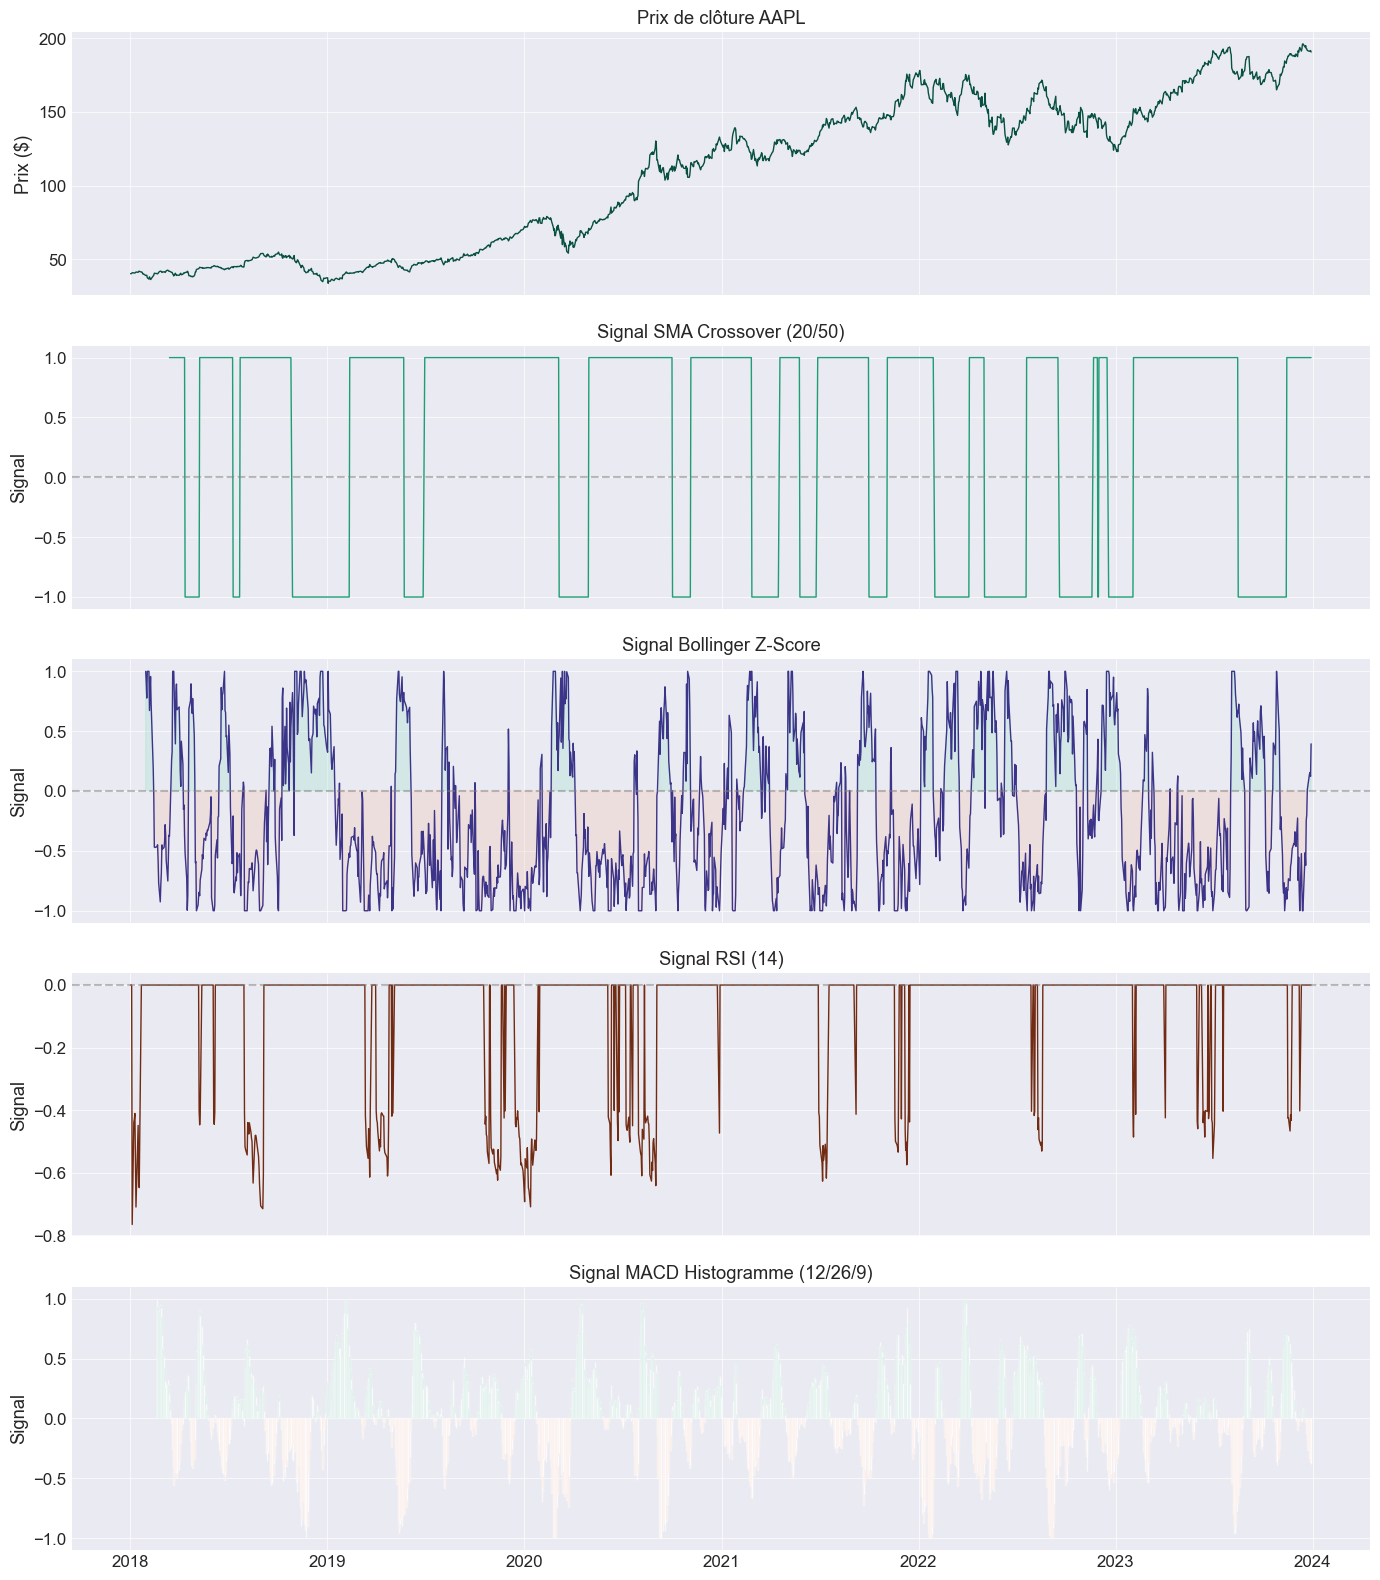

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Prix
axes[0].plot(close.index, close, color="#085041", linewidth=1)
axes[0].set_title("Prix de clôture AAPL")
axes[0].set_ylabel("Prix ($)")

# SMA Crossover
axes[1].plot(sig_sma.index, sig_sma, color="#1D9E75", linewidth=1)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("Signal SMA Crossover (20/50)")
axes[1].set_ylabel("Signal")

# Bollinger
axes[2].plot(sig_boll.index, sig_boll, color="#3C3489", linewidth=1)
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[2].fill_between(sig_boll.index, sig_boll, 0,
                     where=sig_boll > 0, alpha=0.3, color="#9FE1CB")
axes[2].fill_between(sig_boll.index, sig_boll, 0,
                     where=sig_boll < 0, alpha=0.3, color="#F5C4B3")
axes[2].set_title("Signal Bollinger Z-Score")
axes[2].set_ylabel("Signal")

# RSI
axes[3].plot(sig_rsi.index, sig_rsi, color="#712B13", linewidth=1)
axes[3].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[3].set_title("Signal RSI (14)")
axes[3].set_ylabel("Signal")

# MACD
axes[4].bar(sig_macd.index, sig_macd,
            color=["#1D9E75" if v > 0 else "#F0997B" for v in sig_macd],
            width=1, alpha=0.7)
axes[4].set_title("Signal MACD Histogramme (12/26/9)")
axes[4].set_ylabel("Signal")

plt.tight_layout()
plt.show()

In [7]:
bt = Backtester(data, initial_capital=10000)

signals = {
    "SMA Crossover": sig_sma,
    "Bollinger":     sig_boll,
    "RSI":           sig_rsi,
    "MACD":          sig_macd,
}

print(f"{'Stratégie':<20} {'CAGR':>8} {'Sharpe':>8} {'Drawdown':>10} {'Profit F.':>10}")
print("-" * 60)

resultats = {}
for nom, signal in signals.items():
    output = bt.run(signal=signal)
    m = output["metrics"]
    resultats[nom] = output
    print(f"{nom:<20} {m['CAGR (%)']:>7}% "
          f"{m['Sharpe']:>8} "
          f"{m['Max Drawdown (%)']:>9}% "
          f"{m['Profit Factor']:>10}")

Stratégie                CAGR   Sharpe   Drawdown  Profit F.
------------------------------------------------------------
SMA Crossover          18.46%     0.89    -29.09%       1.22
Bollinger              -2.42%     0.02    -39.76%       1.01
RSI                      0.0%      0.0       0.0%        inf
MACD                   27.47%     1.37    -26.74%        1.4


In [8]:
sig_combine = combine_signals(
    signals={
        "sma":  sig_sma,
        "boll": sig_boll,
        "rsi":  sig_rsi,
        "macd": sig_macd,
    },
    weights={
        "sma":  0.4,   # on fait plus confiance à la tendance
        "boll": 0.2,
        "rsi":  0.2,
        "macd": 0.2,
    }
)

output_combine = bt.run(signal=sig_combine)
m = output_combine["metrics"]

print("=== Signal combiné (pondéré) ===")
for k, v in m.items():
    print(f"{k:25} : {v}")

=== Signal combiné (pondéré) ===
CAGR (%)                  : 18.46
Sharpe                    : 0.89
Calmar                    : 0.63
Max Drawdown (%)          : -29.09
Win Rate (%)              : 52.84
Profit Factor             : 1.22
VaR 95% (%)               : -2.07
Capital final (€)         : 27555.79
Nb jours tradés           : 951


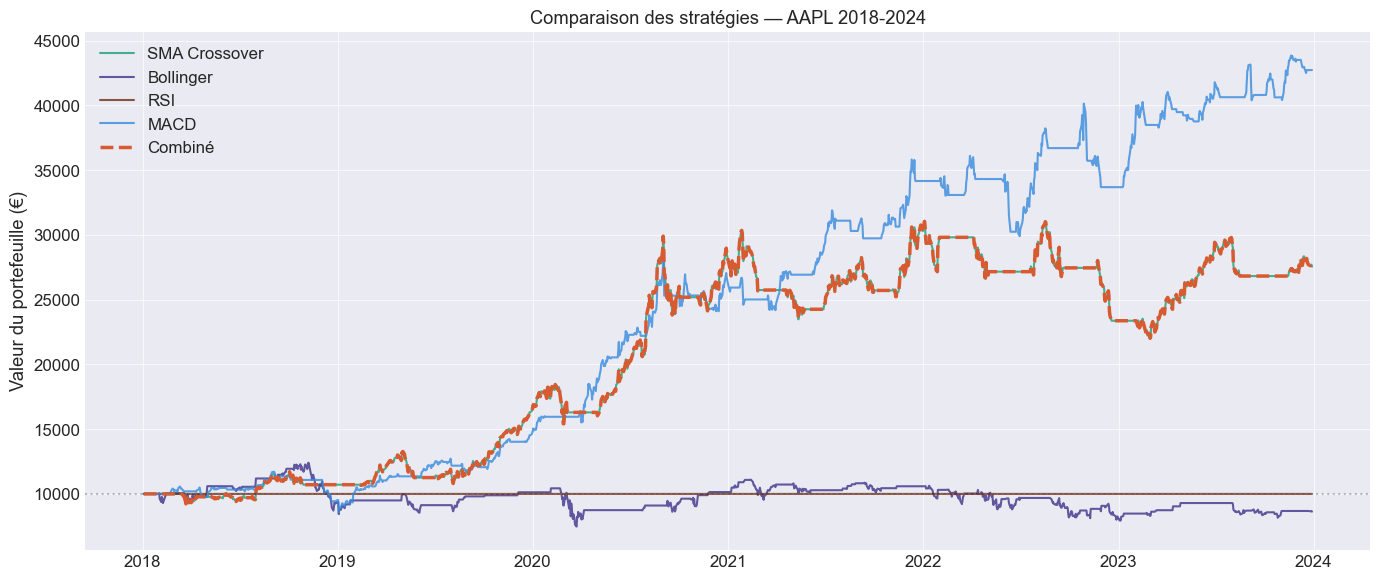

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

couleurs = {
    "SMA Crossover": "#1D9E75",
    "Bollinger":     "#3C3489",
    "RSI":           "#712B13",
    "MACD":          "#378ADD",
}

for nom, output in resultats.items():
    equity = output["results"]["equity_curve"]
    ax.plot(equity.index, equity,
            label=nom, color=couleurs[nom], linewidth=1.5, alpha=0.8)

# Signal combiné
equity_c = output_combine["results"]["equity_curve"]
ax.plot(equity_c.index, equity_c,
        label="Combiné", color="#D85A30",
        linewidth=2.5, linestyle="--")

ax.axhline(y=10000, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Comparaison des stratégies — AAPL 2018-2024")
ax.set_ylabel("Valeur du portefeuille (€)")
ax.legend()
plt.tight_layout()
plt.show()